In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

## Laptops

In [46]:
pd.set_option('display.max_columns', None)

In [47]:
laptops = pd.read_csv(r'data\cleaned\laptops_cleaned.csv')

In [48]:
laptops.isnull().sum()

category                      0
name_card                   979
price                         0
price_old                     0
price_installment             0
rating_card                   0
reviews_card                  0
name_seller                   0
rating_seller                 0
cpu                           0
ssd_capacity                  0
gpu_full_name                 0
os                            0
screen_diagonal               0
ram                           0
auto_time                     0
weight_kg                     0
matrix                        0
ram_type                      0
case_material                 0
cpu_model                     0
processor_brand               0
ghz_processor                 0
processor_cores               0
screen_size                   0
touch_screen                  0
battery_capacity              0
screen_coating                0
gpu_type                      0
brand_graphic_proccessor      0
storage_type                  0
hz_scree

In [49]:
laptops.dropna(inplace=True)

In [50]:
laptops.head()

,category,name_card,price,price_old,price_installment,rating_card,reviews_card,name_seller,rating_seller,cpu,ssd_capacity,gpu_full_name,os,screen_diagonal,ram,auto_time,weight_kg,matrix,ram_type,case_material,cpu_model,processor_brand,ghz_processor,processor_cores,screen_size,touch_screen,battery_capacity,screen_coating,gpu_type,brand_graphic_proccessor,storage_type,hz_screen,web_camera,discount_abs,discount_pct,ram_per_core,high_refresh_rate,cpu_power_proxy,res_w,res_h,pixel_count
0,laptop,"MAIBENBEN Ноутбук 15.6"", Intel Core i5-12450H,...",424220.0,834731.0,25110.0,5.0,2.0,Sotomania,4.8,Intel Core i5-12450H,512.0,Intel UHD Graphics,Windows Pro,15.6,8.0,8.5,1.75,IPS,DDR4,Алюминий,Intel Core i5,Intel,2.0,8.0,1920x1080,Нет,69.3,no_data,no_data,no_data,no_data,60.0,2.0,410511.0,49.18,1.000000,False,16.0,1920.0,1080.0,2073600.0
1,laptop,"HUAWEI MateBook 14 FLMH-X Ноутбук 14.2"", Intel...",523339.0,2251014.0,43612.0,5.0,14.0,Фирменный магазин H...,4.9,Intel Core Ultra 5 125H,1024.0,Intel Arc Graphics,Без системы,14.2,16.0,19.0,1.31,OLED,LPDDR5,Алюминий,Intel Core Ultra 5,Intel,2.6,14.0,2880x1920,Да,70.0,Глянцевое,Встроенная,Intel,SSD,120.0,2.0,1727675.0,76.75,1.142857,True,36.4,2880.0,1920.0,5529600.0
2,laptop,"Apple Ноутбук 11.6"", RAM 4 ГБ, SSD 128 ГБ, Mac...",424220.0,834731.0,27878.0,4.9,30.0,Comp+,4.9,no_data,128.0,no_data,MacOS,11.6,4.0,7.0,1.70,no_data,no_data,no_data,Intel Core i5,no_data,2.6,8.0,no_data,no_data,56.0,no_data,no_data,no_data,SSD,60.0,2.0,410511.0,49.18,0.500000,False,20.8,1920.0,1080.0,2073600.0
3,laptop,Ноутбук,424220.0,834731.0,19765.0,4.3,3.0,Полюс,4.9,no_data,512.0,no_data,no_data,15.6,16.0,7.0,1.70,no_data,no_data,no_data,no_data,no_data,2.6,8.0,no_data,no_data,56.0,no_data,no_data,no_data,no_data,60.0,2.0,410511.0,49.18,2.000000,False,20.8,1920.0,1080.0,2073600.0
4,laptop,"AMDR5 Ноутбук 15.6"", RAM 32 ГБ 2048 ГБ, AMD Ra...",257297.0,604910.0,21442.0,5.0,13.0,hassenda,4.8,no_data,2048.0,AMD Radeon,Windows Pro,15.6,32.0,7.0,1.70,no_data,DDR4,no_data,AMD Ryzen 5,AMD,2.0,4.0,1920x1080,no_data,80.0,no_data,no_data,AMD,no_data,120.0,5.0,347613.0,57.47,8.000000,True,8.0,1920.0,1080.0,2073600.0


In [51]:
laptops['processor_brand'].value_counts()

processor_brand
Intel       2844
AMD          936
Apple        311
no_data      290
Qualcomm       9
MediaTek       7
Name: count, dtype: int64

In [52]:
counts = laptops['name_seller'].value_counts()
seller_size_map = pd.qcut(counts, q=3, labels=['Small', 'Medium', 'Large']).to_dict()
laptops['seller_category'] = laptops['name_seller'].map(seller_size_map)
print(laptops['seller_category'].value_counts())

seller_category
Large     3524
Medium     573
Small      300
Name: count, dtype: int64


In [53]:
X = laptops.drop(columns=['price'])
y = laptops['price']

In [54]:
numerical = X.select_dtypes(include=np.number).columns

test = laptops[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

              feature        VIF
22        pixel_count  69.695069
21              res_h  47.176010
1           price_old  37.056631
16       discount_abs  36.643287
20              res_w  34.724263
19    cpu_power_proxy  12.953936
12    processor_cores   8.581957
18       ram_per_core   4.938390
11      ghz_processor   4.747670
8                 ram   4.742595
2   price_installment   2.830672
14          hz_screen   2.151513
10          weight_kg   1.990326
17       discount_pct   1.869750
7     screen_diagonal   1.728545
6        ssd_capacity   1.400548
15         web_camera   1.320397
9           auto_time   1.265255
5       rating_seller   1.209259
4        reviews_card   1.070523
3         rating_card   1.057554
13   battery_capacity   1.012181


In [55]:
X = X.drop(columns = ['pixel_count', 'name_seller', 'discount_abs', 'res_h', 'cpu_power_proxy'])

In [56]:
numerical = X.select_dtypes(include=np.number).columns

test = laptops[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

              feature       VIF
17       ram_per_core  4.623446
8                 ram  4.622373
2   price_installment  2.609429
12    processor_cores  2.362677
18              res_w  2.093870
14          hz_screen  2.057778
10          weight_kg  1.873646
1           price_old  1.840201
7     screen_diagonal  1.626503
16       discount_pct  1.399902
6        ssd_capacity  1.393830
15         web_camera  1.287014
9           auto_time  1.258582
11      ghz_processor  1.232163
5       rating_seller  1.194917
3         rating_card  1.055660
4        reviews_card  1.054963
13   battery_capacity  1.011305


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [58]:
norm = laptops[numerical].drop(columns=['price_old', 'price_installment', 'res_w', 'discount_pct']).columns.to_list()

In [59]:
huge_feat_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('huge', huge_feat_pipe, ['price_old', 'price_installment', 'res_w']),
    ('norm', StandardScaler(), norm),
    ('OHE', OneHotEncoder(handle_unknown='ignore'), ['os', 'processor_brand', 'high_refresh_rate', 'seller_category'])
])

In [60]:
target_pipe = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), ['price'])
])

In [61]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [62]:
param_dist = {
    'model__alpha': loguniform(1e-3, 1e3),
    'model__fit_intercept': [True, False],
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

In [63]:
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [64]:
ridge_search.fit(X_train, target_pipe.fit_transform(y_train.to_frame()).ravel())

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': <scipy.stats....001B9FC3170E0>, 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [65]:
print("Best params:", ridge_search.best_params_)
print("Best RMSE:", -ridge_search.best_score_)

Best params: {'model__alpha': np.float64(1.36897959935922), 'model__fit_intercept': True, 'model__solver': 'svd'}
Best RMSE: 0.2669229442971968


In [66]:
best_ridge = ridge_search.best_estimator_

In [67]:
y_pred = best_ridge.predict(X_test)
y_pred_exp = np.expm1(y_pred)

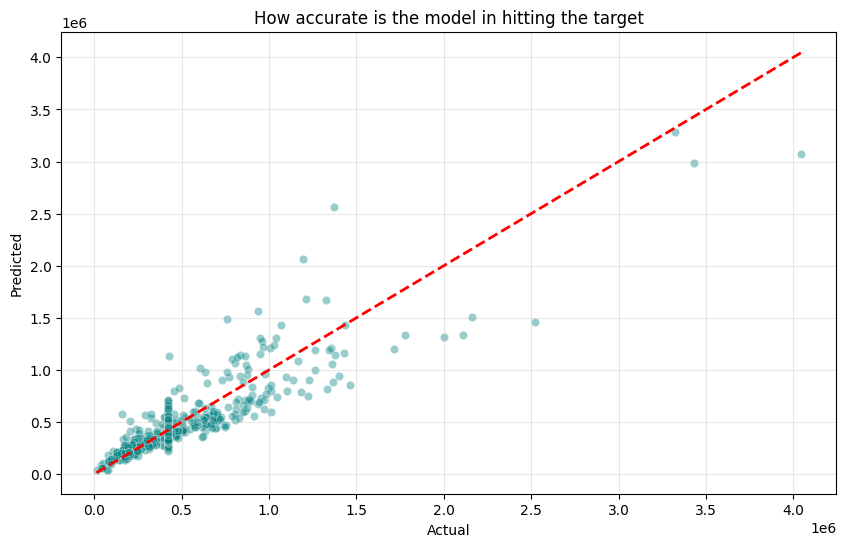

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_exp, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('How accurate is the model in hitting the target')
plt.grid(True, alpha=0.3)
plt.show()

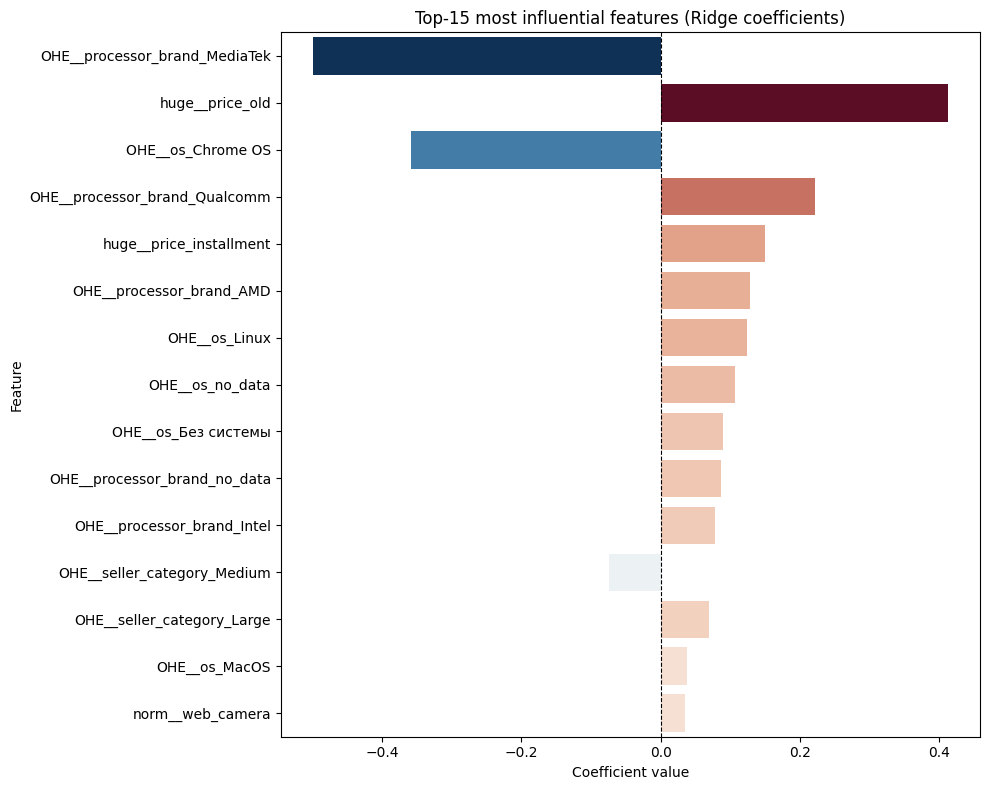

In [69]:
feature_names = best_ridge.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_ridge.named_steps['model'].coef_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=feat_imp_df.head(15),
    palette='RdBu_r',
    hue='coefficient',
    legend=False
)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top-15 most influential features (Ridge coefficients)')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Without highly correlated features

In [70]:
X_new = X.drop(columns=['price_old', 'price_installment', 'res_w'])

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.15, random_state=42)

In [72]:
preprocessor = ColumnTransformer([
    ('OHE', OneHotEncoder(handle_unknown='ignore'), ['os', 'processor_brand', 'high_refresh_rate', 'seller_category']),
    ('norm', StandardScaler(), norm)
])

In [73]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [74]:
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [75]:
ridge_search.fit(X_train, target_pipe.fit_transform(y_train.to_frame()).ravel())

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': <scipy.stats....001B9FC3170E0>, 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [76]:
best_ridge = ridge_search.best_estimator_

In [77]:
y_pred = best_ridge.predict(X_test)
y_pred_exp = np.expm1(y_pred)

In [78]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_exp)))
print("Test R^2:", r2_score(y_test, y_pred_exp))

Test RMSE: 268092.65192123095
Test R^2: 0.4430369420334601


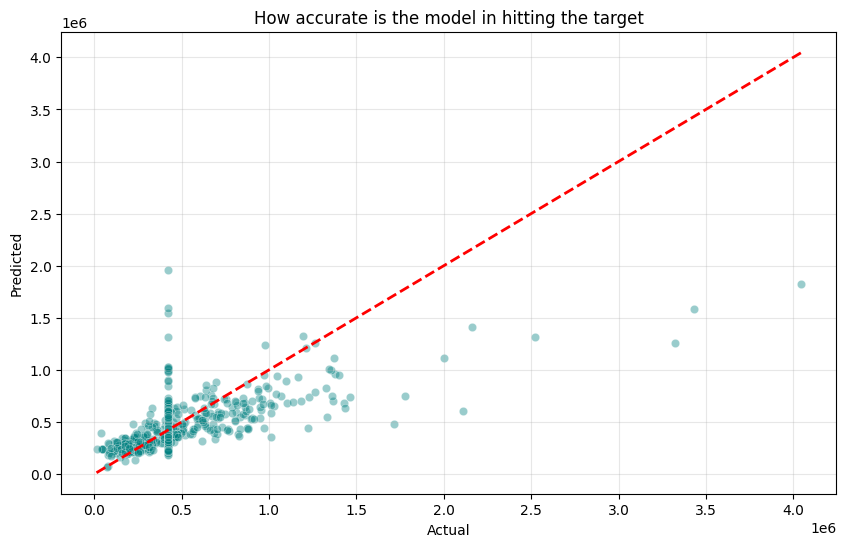

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_exp, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('How accurate is the model in hitting the target')
plt.grid(True, alpha=0.3)
plt.show()

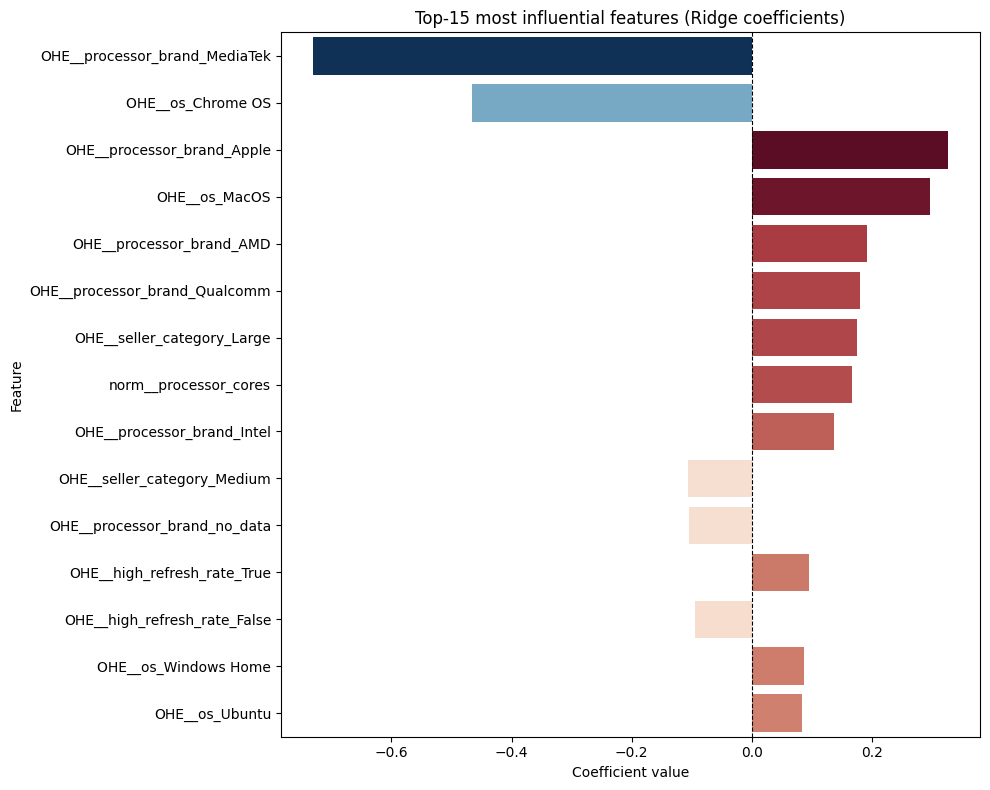

In [80]:
feature_names = best_ridge.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_ridge.named_steps['model'].coef_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=feat_imp_df.head(15),
    palette='RdBu_r',
    hue='coefficient',
    legend=False
)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top-15 most influential features (Ridge coefficients)')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# CatBoost (without highly correlated features)

In [81]:
cat_cols = [
    'os', 'processor_brand', 'matrix', 'ram_type', 'case_material',
    'cpu_model', 'touch_screen', 'screen_coating', 'gpu_type',
    'brand_graphic_proccessor', 'storage_type', 'high_refresh_rate',
    'seller_category'
]

num_cols = norm

In [82]:
cb_features = num_cols + [c for c in cat_cols if c in X_new.columns]
X_cb = X_new[cb_features].copy()

for c in cat_cols:
    if c in X_cb.columns:
        X_cb[c] = X_cb[c].astype(str).fillna('no_data')

cat_indices = [X_cb.columns.tolist().index(c) for c in cat_cols if c in X_cb.columns]

In [83]:
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_cb, y, test_size=0.15, random_state=42
)

In [84]:
y_train_log = np.log1p(y_train_cb)
y_test_log  = np.log1p(y_test_cb)

In [85]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

cb_model.fit(
    X_train_cb, y_train_log,
    cat_features=cat_indices,
    eval_set=(X_test_cb, y_test_log)
)

0:	learn: 0.6121461	test: 0.5848352	best: 0.5848352 (0)	total: 71.4ms	remaining: 1m 11s
100:	learn: 0.3862192	test: 0.3823852	best: 0.3823852 (100)	total: 7.09s	remaining: 1m 3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3776414621
bestIteration = 147

Shrink model to first 148 iterations.


In [86]:
y_pred_log = cb_model.predict(X_test_cb)
y_pred_cb  = np.expm1(y_pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2        = r2_score(y_test_cb, y_pred_cb)

print(f"CatBoost RMSE (log scale): {rmse_log:.4f}")
print(f"CatBoost R²  (orig scale): {r2:.4f}")

CatBoost RMSE (log scale): 0.3776
CatBoost R²  (orig scale): 0.5415


C:\Users\raibe\AppData\Local\Temp\ipykernel_21412\1848525312.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis', ax=axes[1])


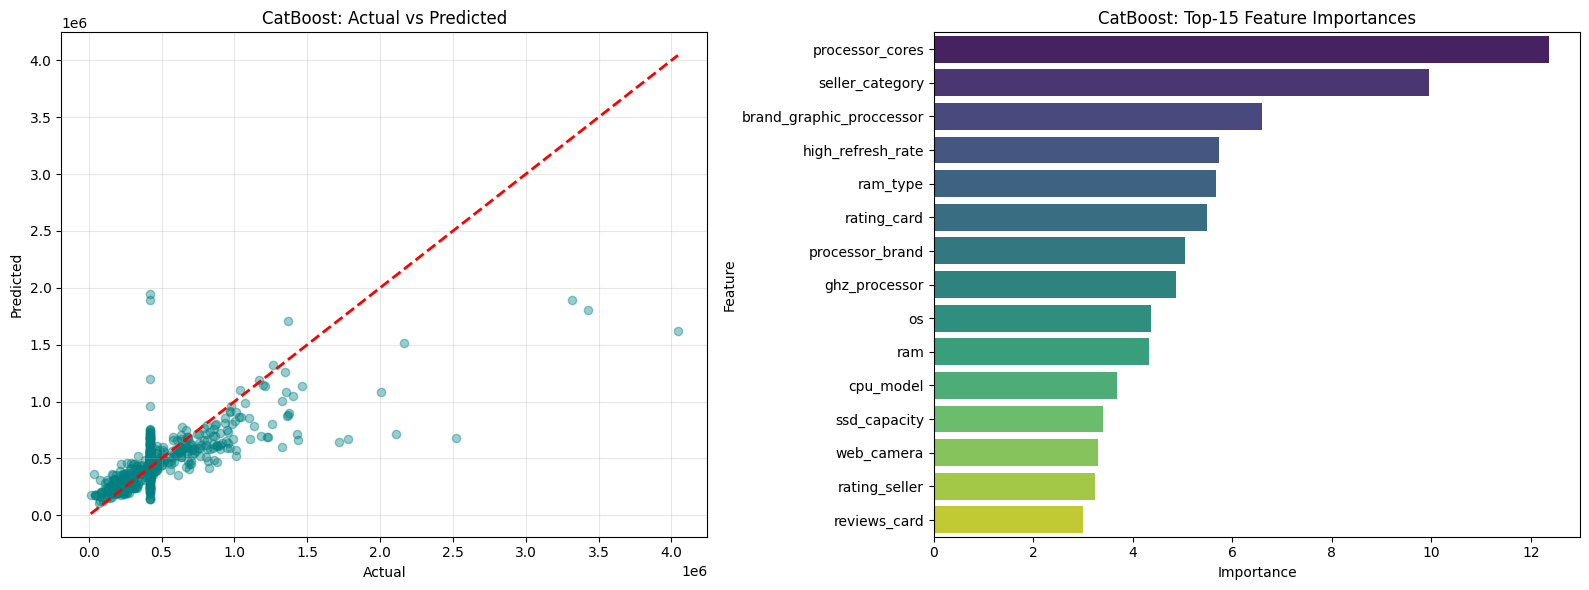

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_cb, y_pred_cb, alpha=0.4, color='teal')
axes[0].plot([y_test_cb.min(), y_test_cb.max()], [y_test_cb.min(), y_test_cb.max()], '--r', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('CatBoost: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

feat_imp = pd.DataFrame({
    'feature': X_cb.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(15)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis', ax=axes[1])
axes[1].set_title('CatBoost: Top-15 Feature Importances')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()